# 第 8 章 · TransE 与 Attention

向量平移嵌入 + 解码端软对齐。

配套交互演示：[章节网页](../ch8.html)

## 本节目标

- TransE 距离与 margin
- Attention softmax 权重

## 1. TransE 嵌入

希望 **h + r ≈ t**；正例距离小，负例 tail 替换后距离大。

**TransE**

```text
d = ||h + r - t||
loss = max(0, d+ + margin - d-)
```

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "labs").exists() and (ROOT.parent / "labs").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "labs"))
sys.path.insert(0, str(ROOT / "labs" / "ch08"))
import matplotlib.pyplot as plt
from common.mpl_setup import configure_matplotlib
configure_matplotlib()
from IPython.display import display, Image
from neural import *

In [2]:
transe_demo()

正例 (鲁迅,创作,呐喊) d+=0.31
负例尾「红楼梦」 d-=2.08
margin loss: max(0, 0.31+1-2.08)=0.00


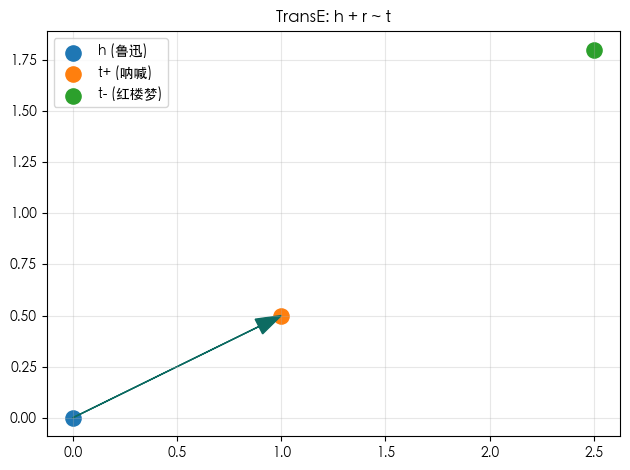

In [3]:
plot_transe()

**思考** · 正例 d+ 约多少？

<details><summary>查看答案</summary>

0.31，小于负例 2.08。

</details>

## 2. Cross-Attention

解码端 query「写」对 encoder 各 token 算 score，softmax 得权重 α。

**Attention**

```text
scores = QK^T
alpha = softmax(scores)
```

In [4]:
attention_demo()

tokens: ['鲁迅', '写', '日记']
  鲁迅: score=0.4 α=0.14 (网页 0.05)
  写: score=2.1 α=0.74 (网页 0.80)
  日记: score=0.3 α=0.12 (网页 0.15)


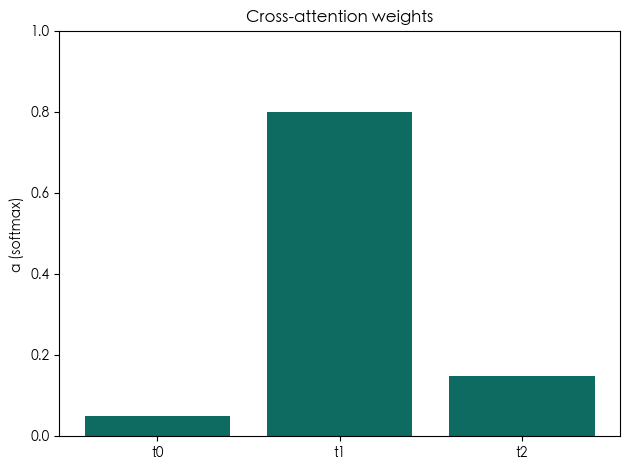

In [5]:
plot_attention()

**思考** · 「写」的 α 最大？

<details><summary>查看答案</summary>

约 0.80，t1 对应「写」。

</details>

## 小结

TransE=几何平移；Attention=软查询。对照 [ch8.html](../ch8.html)。

## 练习

1. margin 增大对 loss 影响？
2. α 和为 1 保证什么？